# 🤖 AirLyst: [04] Model Training & Evaluation
**Mission: Teach the Machine**

In this notebook, we take our engineered features and train a Machine Learning model to predict the **US AQI**. We will focus on building a robust model that understands the relationship between weather, historical patterns, and air quality.

---

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Setup Path
ROOT_DIR = Path("C:/Users/Dell/Desktop/AirLyst")
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from backend.config.settings import settings

print("Model Training Engine Ready.")

Model Training Engine Ready.


## 📂 1. Load Engineered Features

In [24]:
data_path = ROOT_DIR / "backend/data/engineered_features.csv"
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'])

print(f"Loaded {len(df)} rows for training.")
df.head()

Loaded 13152 rows for training.


,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,us_aqi,temperature_2m,surface_pressure,wind_speed_10m,...,pm2_5_lag_1h,pm2_5_lag_3h,pm2_5_lag_6h,pm2_5_lag_24h,us_aqi_lag_1h,us_aqi_lag_3h,us_aqi_lag_6h,us_aqi_lag_24h,pm2_5_rolling_6h,pm2_5_rolling_24h
0,2024-11-14 00:00:00,116.4,109.7,1027.0,79.9,14.5,156,16.2,947.3,6.7,...,116.2,121.1,96.4,104.1,156.0,156.0,156.0,151.0,115.700000,67.841667
1,2024-11-14 01:00:00,106.4,100.8,822.0,72.1,11.9,156,16.1,947.2,6.0,...,109.7,119.7,109.2,92.9,156.0,156.0,156.0,152.0,114.300000,68.170833
2,2024-11-14 02:00:00,98.0,92.7,721.0,64.8,10.0,157,16.6,947.2,3.9,...,100.8,116.2,118.3,81.3,156.0,156.0,156.0,153.0,110.033333,68.645833
3,2024-11-14 03:00:00,90.1,85.2,678.0,57.5,9.1,157,17.2,947.3,2.0,...,92.7,109.7,121.1,70.5,157.0,156.0,156.0,154.0,104.050000,69.258333
4,2024-11-14 04:00:00,79.9,76.4,739.0,50.7,8.9,157,16.2,947.3,4.4,...,85.2,100.8,119.7,60.8,157.0,156.0,156.0,155.0,96.833333,69.908333


## ✂️ 2. Train-Test Split

In [25]:
drop_cols = ['time', 'us_aqi', 'aqi_status']
X = df.drop(columns=drop_cols)
y = df['us_aqi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Training set: 10521 rows
Testing set: 2631 rows


## 🏗️ 3. Model Training (Random Forest)

In [26]:
print(" Training Random Forest Model... (Using all CPU cores)")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(" Training Complete!")

 Training Random Forest Model... (Using all CPU cores)
 Training Complete!


## 📊 4. Evaluation (Actual vs Predicted)

--- [MODEL PERFORMANCE] ---
MAE (Mean Absolute Error): 1.23
RMSE (Root Mean Squared Error): 3.03
R2 Score (Accuracy): 0.9911

--- [SAMPLE PREDICTIONS vs ACTUAL] ---
   Actual AQI  Predicted AQI  Error
0         115            115      0
1          42             42      0
2          54             54      0
3          89             90      1
4         127            127      0
5         111            111      0
6         104            104      0
7         113            114      1
8          92             92      0
9         152            154      2


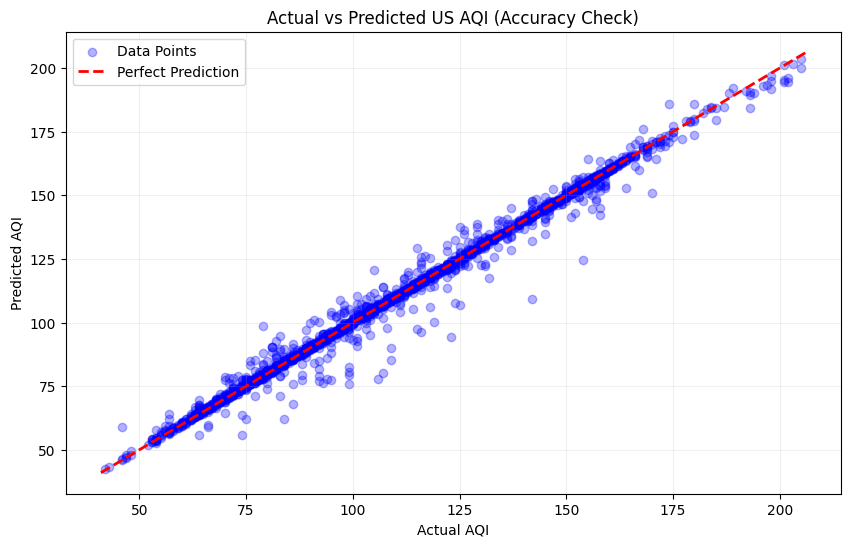

In [34]:
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- [MODEL PERFORMANCE] ---")
print(f"MAE (Mean Absolute Error): {mae:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"R2 Score (Accuracy): {r2:.4f}")

# Show Sample Predictions with Correct Rounding
print("\n--- [SAMPLE PREDICTIONS vs ACTUAL] ---")

# Hum pehle round karte hain, phir integer mein convert karte hain
rounded_pred = np.round(y_pred[:10]).astype(int)
actual_values = y_test.values[:10]

comparison = pd.DataFrame({
    'Actual AQI': actual_values,
    'Predicted AQI': rounded_pred,
    'Error': np.abs(actual_values - rounded_pred) # Ab error bilkul sahi aayega
})
print(comparison)

#  Visualize: Actual vs Predicted (Linear Scatter Plot)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue', label='Data Points')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted US AQI (Accuracy Check)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


## 🌲 5. Feature Importance

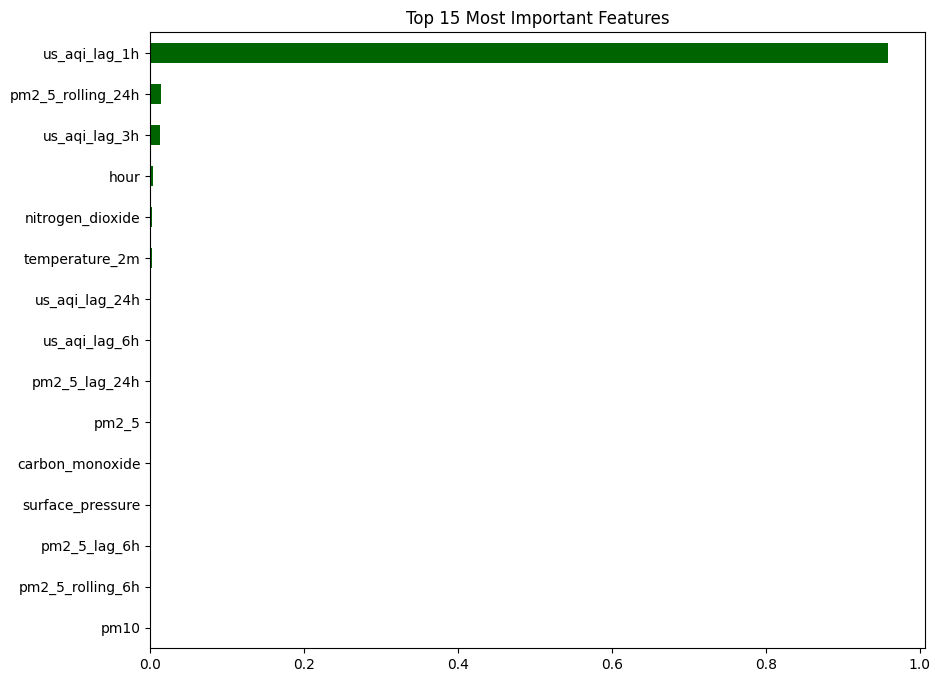

In [35]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh', color='darkgreen')
plt.title("Top 15 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

## 💾 6. Save Model

In [36]:
import joblib
model_path = ROOT_DIR / "backend/models/aqi_model.joblib"
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model, model_path)
print(f" Model saved to {model_path}")

 Model saved to C:\Users\Dell\Desktop\AirLyst\backend\models\aqi_model.joblib
